# 03 Disease-Associated Expression Analysis

This notebook examines disease-associated gene expression patterns in selected immune cell populations from an inflammatory bowel disease single-cell RNA-seq dataset.

The goal is to compare transcriptional differences across healthy, non-inflamed, and inflamed intestinal tissue, focusing on immune populations that showed meaningful composition changes or biologically relevant marker profiles in previous notebooks.

## 1. Setup

Import analysis libraries, configure plotting settings, and suppress non-critical performance warnings.

In [1]:
from pathlib import Path
import warnings

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.errors import PerformanceWarning

warnings.simplefilter("ignore", PerformanceWarning)

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, facecolor="white")

## 2. Load Processed Immune Cell Dataset

Load the immune-cell AnnData object prepared in the data exploration notebook.

In [2]:
processed_data_path = Path("../data/processed/immune_cells_with_metadata.h5ad")

adata = sc.read_h5ad(processed_data_path)

adata

AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'

## 3. Prepare Expression Data

Normalize and log-transform expression values for disease-associated expression analysis. If raw counts are not already stored in a layer, they are preserved before normalization.

In [3]:
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

normalizing counts per cell
    finished (0:00:07)


AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'
    uns: 'log1p'
    layers: 'counts'

## 4. Inspect Condition Labels

Confirm the number of cells available for each tissue condition.

In [4]:
adata.obs["Health"].value_counts()

Health
Inflamed        91830
Non-inflamed    67412
Healthy         51372
Name: count, dtype: int64

## 5. Select A Cell Population For Disease-Associated Analysis

Macrophages are selected for the first condition-specific expression analysis because myeloid cells are central mediators of intestinal inflammation and were present as a major immune population in the dataset.

Analyzing one cell population at a time avoids confounding disease-associated expression changes with broad differences between immune cell types.

In [6]:
cell_type = "Macrophages"

cell_adata = adata[adata.obs["Cluster"] == cell_type].copy()

cell_adata

AnnData object with n_obs × n_vars = 16692 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'
    uns: 'log1p'
    layers: 'counts'

## 6. Inspect Condition Representation Within Selected Cells

Before differential expression testing, confirm that the selected cell population contains cells from each tissue condition.

In [7]:
cell_adata.obs["Health"].value_counts()

Health
Inflamed        7162
Non-inflamed    5945
Healthy         3585
Name: count, dtype: int64

## 7. Differential Expression Across Tissue Conditions

Differential expression is performed within the selected immune population by comparing tissue conditions. Here, inflamed tissue is compared against healthy tissue to identify genes associated with active intestinal inflammation.

In [8]:
sc.tl.rank_genes_groups(
    cell_adata,
    groupby="Health",
    groups=["Inflamed"],
    reference="Healthy",
    method="wilcoxon",
    key_added="inflamed_vs_healthy"
)

ranking genes
    finished: added to `.uns['inflamed_vs_healthy']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:11)


## 8. Convert Differential Expression Results To A Table

The inflamed-versus-healthy macrophage differential expression results are converted into a table for inspection, filtering, and saving.

In [9]:
macrophage_de = sc.get.rank_genes_groups_df(
    cell_adata,
    group="Inflamed",
    key="inflamed_vs_healthy"
)

macrophage_de.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MALAT1,45.838917,2.860634,0.000000e+00,0.000000e+00
1,S100A6,44.159744,2.691585,0.000000e+00,0.000000e+00
2,RPL39,43.613239,2.256023,0.000000e+00,0.000000e+00
3,NEAT1,40.950939,2.325158,0.000000e+00,0.000000e+00
4,S100A9,39.425312,4.165968,0.000000e+00,0.000000e+00
5,S100A8,37.880020,7.839770,0.000000e+00,0.000000e+00
6,MT-ND3,37.271877,2.211003,4.686529e-304,4.373171e-301
7,RPL34,37.002590,1.181218,1.040459e-299,8.899828e-297
8,RPS24,32.229889,0.965794,6.732204e-228,4.318919e-225
9,RPL21,32.209030,0.765964,1.319145e-227,8.206283e-225


## 9. Filter Significant Disease-Associated Genes

Genes are filtered using adjusted p-value and log-fold-change thresholds to identify stronger disease-associated candidates.

In [10]:
significant_macrophage_de = macrophage_de[
    (macrophage_de["pvals_adj"] < 0.05) &
    (macrophage_de["logfoldchanges"].abs() > 0.5)
].copy()

significant_macrophage_de.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,MALAT1,45.838917,2.860634,0.000000e+00,0.000000e+00
1,S100A6,44.159744,2.691585,0.000000e+00,0.000000e+00
2,RPL39,43.613239,2.256023,0.000000e+00,0.000000e+00
3,NEAT1,40.950939,2.325158,0.000000e+00,0.000000e+00
4,S100A9,39.425312,4.165968,0.000000e+00,0.000000e+00
5,S100A8,37.880020,7.839770,0.000000e+00,0.000000e+00
6,MT-ND3,37.271877,2.211003,4.686529e-304,4.373171e-301
7,RPL34,37.002590,1.181218,1.040459e-299,8.899828e-297
8,RPS24,32.229889,0.965794,6.732204e-228,4.318919e-225
9,RPL21,32.209030,0.765964,1.319145e-227,8.206283e-225


## 10. Save Macrophage Differential Expression Results

The full and filtered macrophage differential expression result tables are saved as project outputs.

In [11]:
macrophage_de_path = "../results/tables/macrophage_inflamed_vs_healthy_all_genes.csv"
significant_macrophage_de_path = "../results/tables/macrophage_inflamed_vs_healthy_significant_genes.csv"

macrophage_de.to_csv(macrophage_de_path, index=False)
significant_macrophage_de.to_csv(significant_macrophage_de_path, index=False)

macrophage_de_path, significant_macrophage_de_path

('../results/tables/macrophage_inflamed_vs_healthy_all_genes.csv',
 '../results/tables/macrophage_inflamed_vs_healthy_significant_genes.csv')

## 11. Initial Macrophage Differential Expression Interpretation

The inflamed-versus-healthy macrophage comparison identifies several genes with higher expression in inflamed tissue. Some of the strongest genes, including `S100A8` and `S100A9`, are consistent with inflammatory myeloid activation and are biologically relevant in intestinal inflammation.

Other highly ranked genes, including ribosomal genes, mitochondrial genes, and long non-coding RNAs such as `MALAT1` and `NEAT1`, should be interpreted cautiously. These genes may reflect broad changes in cell state, stress, sequencing depth, or technical effects rather than specific inflammatory pathways.

For this reason, downstream interpretation will focus on biologically interpretable immune and inflammatory genes rather than relying only on the top-ranked genes by statistical score.

## 12. Visualize Selected Inflammatory Genes In Macrophages

Selected inflammatory and myeloid-associated genes are visualized across tissue conditions within macrophages.

In [12]:
candidate_genes = [
    "S100A8",
    "S100A9",
    "S100A6",
    "LYZ",
    "IL1B",
    "TNF",
    "CXCL8",
    "CCL3",
    "CCL4",
]

available_candidate_genes = [
    gene for gene in candidate_genes
    if gene in cell_adata.var_names
]

available_candidate_genes

['S100A8', 'S100A9', 'S100A6', 'LYZ', 'IL1B', 'TNF', 'CCL3', 'CCL4']

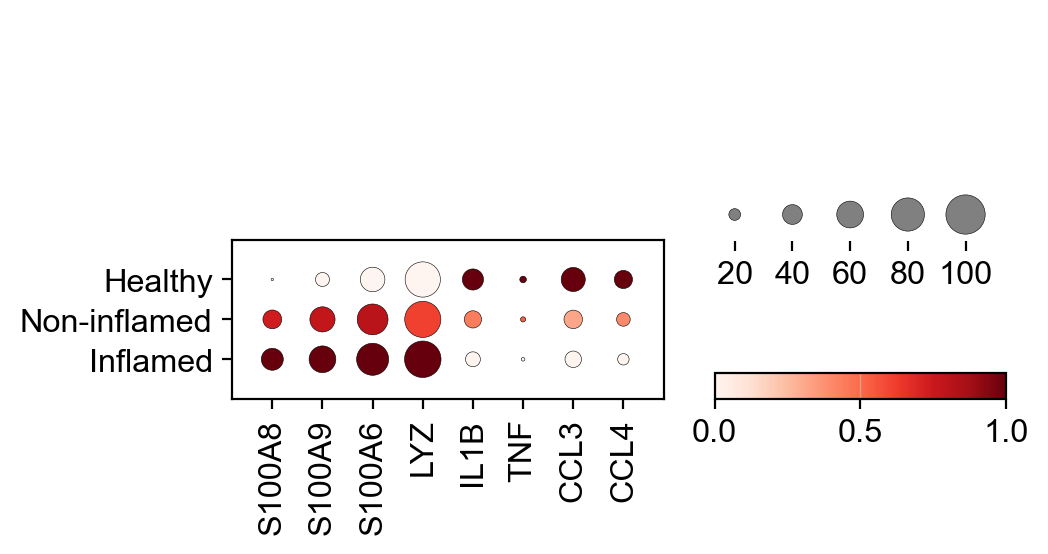

In [14]:
cell_adata.obs["Health"] = pd.Categorical(
    cell_adata.obs["Health"],
    categories=["Healthy", "Non-inflamed", "Inflamed"],
    ordered=True
)

sc.pl.dotplot(
    cell_adata,
    var_names=available_candidate_genes,
    groupby="Health",
    standard_scale="var",
    dendrogram=False,
    show=False
)

plt.savefig(
    "../results/figures/macrophage_inflammatory_gene_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Macrophage Inflammatory Gene Interpretation

The macrophage inflammatory gene dot plot shows condition-associated differences in selected myeloid and inflammatory genes. `S100A8`, `S100A9`, `S100A6`, and `LYZ` show stronger expression patterns in inflamed and/or non-inflamed IBD-associated macrophages compared with healthy macrophages, supporting an inflammatory myeloid signature in disease-associated tissue.

The `S100A8` and `S100A9` signal is particularly notable because these genes are commonly associated with inflammatory monocyte/macrophage states. In contrast, genes such as `IL1B`, `CCL3`, and `CCL4` show condition-specific patterns that should be interpreted cautiously and may require further analysis at the donor level or within finer macrophage subclusters.

Overall, this analysis suggests that macrophages from IBD-associated tissue display transcriptional features consistent with inflammatory myeloid activation.

## Notebook Summary

This notebook examined disease-associated gene expression in macrophages from healthy, non-inflamed, and inflamed intestinal tissue.

Within macrophages, the inflamed-versus-healthy comparison identified genes associated with inflammatory myeloid activation, including `S100A8`, `S100A9`, and `S100A6`. These genes showed stronger expression patterns in IBD-associated tissue and support the presence of disease-associated macrophage states.

The analysis also highlighted the importance of cautious interpretation: some highly ranked genes, including ribosomal, mitochondrial, and long non-coding RNA genes, may reflect broad cell state or technical effects rather than specific inflammatory pathways.

Overall, this notebook provides an initial disease-associated expression analysis and identifies macrophage inflammatory programs as a candidate focus for downstream pathway-level interpretation.